In [1]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="***",
    host="localhost",
    port=3306,
    database="encommerce_analysis"
)
engine = create_engine(url)

In [2]:
# 读取SQL里的表格
sql = """
SELECT DATE_FORMAT(order_purchase_timestamp,'%%Y-%%m') AS months,
       SUM(price) AS m_total_sales,
       COUNT(DISTINCT orders.order_id) AS m_order_count,
       COUNT(DISTINCT customer_unique_id) AS m_customer_count,
       SUM(price)/COUNT(DISTINCT orders.order_id) AS m_avg_order_value
FROM orders
JOIN order_items ON orders.order_id = order_items.order_id
JOIN customer ON orders.customer_id = customer.customer_id
WHERE order_status = 'delivered'
GROUP BY months
ORDER BY months;
"""

monthly_sales = pd.read_sql(sql, engine)
print(monthly_sales)

     months  m_total_sales  m_order_count  m_customer_count  m_avg_order_value
0   2016-09         134.97              1                 1         134.970000
1   2016-10       40325.11            265               262         152.170226
2   2016-12          10.90              1                 1          10.900000
3   2017-01      111798.36            750               718         149.064480
4   2017-02      234223.40           1653              1630         141.695947
5   2017-03      359198.85           2546              2508         141.083602
6   2017-04      340669.68           2303              2274         147.924307
7   2017-05      489338.25           3546              3479         137.997250
8   2017-06      421923.37           3135              3076         134.584807
9   2017-07      481604.52           3872              3802         124.381333
10  2017-08      554699.70           4193              4114         132.291844
11  2017-09      607399.67           4150           

In [8]:
monthly_sales["months"] = pd.to_datetime(monthly_sales["months"]) # 将日期列字符格式改为时间格式
# 检查数据结构与数据质量
print(monthly_sales.shape) # 表格数据数量
print(monthly_sales.isnull().sum()) # 查看表格的空值数量
print(monthly_sales.info())
print(monthly_sales.describe())

(23, 5)
months               0
m_total_sales        0
m_order_count        0
m_customer_count     0
m_avg_order_value    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   months             23 non-null     datetime64[ns]
 1   m_total_sales      23 non-null     float64       
 2   m_order_count      23 non-null     int64         
 3   m_customer_count   23 non-null     int64         
 4   m_avg_order_value  23 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 1.0 KB
None
                              months  m_total_sales  m_order_count  \
count                             23      23.000000      23.000000   
mean   2017-08-28 20:52:10.434782720  574847.743913    4194.695652   
min              2016-09-01 00:00:00      10.900000       1.000000   
25%              2017-0

In [9]:
# 查看数据的完整性，决定适合进行数据分析的区间
print(monthly_sales.head())
print(monthly_sales.tail())

      months  m_total_sales  m_order_count  m_customer_count  \
0 2016-09-01         134.97              1                 1   
1 2016-10-01       40325.11            265               262   
2 2016-12-01          10.90              1                 1   
3 2017-01-01      111798.36            750               718   
4 2017-02-01      234223.40           1653              1630   

   m_avg_order_value  
0         134.970000  
1         152.170226  
2          10.900000  
3         149.064480  
4         141.695947  
       months  m_total_sales  m_order_count  m_customer_count  \
18 2018-04-01      973534.09           6798              6744   
19 2018-05-01      977544.69           6749              6693   
20 2018-06-01      856077.86           6099              6061   
21 2018-07-01      867953.46           6159              6100   
22 2018-08-01      838576.64           6351              6310   

    m_avg_order_value  
18         143.208898  
19         144.842894  
20         140

In [10]:
# 从原表格中取出符合分析条件的数据，并生成新的数据集
monthly_sales_analysis = monthly_sales[
    monthly_sales["months"] >= "2017-01-01"].copy()
# 找到销量最高的数据对应的行数据
max_sales_month = monthly_sales_analysis.loc[
    monthly_sales_analysis["m_total_sales"].idxmax()]
print(max_sales_month)
# 找到销量最低的数据对应的行数据
min_sales_month = monthly_sales_analysis.loc[
    monthly_sales_analysis["m_total_sales"].idxmin()]
print(min_sales_month)

# 开始计算各个销售量分析指标
sales_growth = (
    (max_sales_month["m_total_sales"] - min_sales_month["m_total_sales"])
    / min_sales_month["m_total_sales"])*100
order_growth = (
    (max_sales_month["m_order_count"] - min_sales_month["m_order_count"])
    / min_sales_month["m_order_count"]) * 100
customer_growth = (
    (max_sales_month["m_customer_count"] - min_sales_month["m_customer_count"])
    / min_sales_month["m_customer_count"]) * 100
aov_growth = (
    (max_sales_month["m_avg_order_value"] - min_sales_month["m_avg_order_value"])
    / min_sales_month["m_avg_order_value"]) * 100
print("销售额增长率：",sales_growth)
print("订单数增长率：",order_growth)
print("客户数增长率：",customer_growth)
print("客单价增长率：",aov_growth)

months               2017-11-01 00:00:00
m_total_sales                  987765.37
m_order_count                       7289
m_customer_count                    7183
m_avg_order_value             135.514525
Name: 13, dtype: object
months               2017-01-01 00:00:00
m_total_sales                  111798.36
m_order_count                        750
m_customer_count                     718
m_avg_order_value              149.06448
Name: 3, dtype: object
销售额增长率： 783.5240248604721
订单数增长率： 871.8666666666668
客户数增长率： 900.4178272980502
客单价增长率： -9.089995819258895


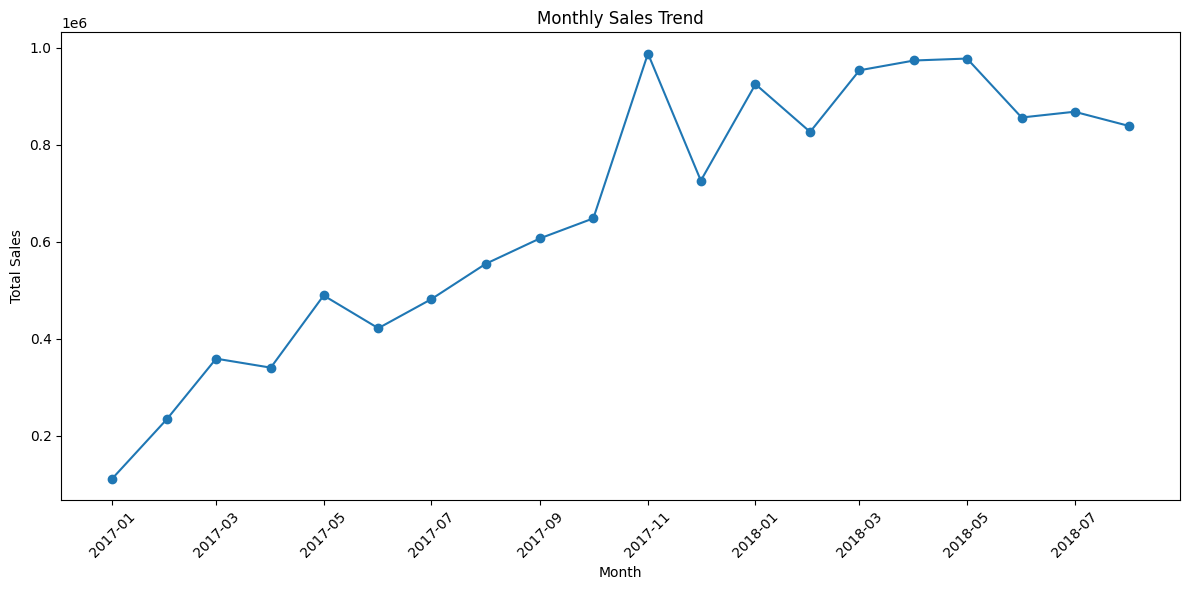

In [11]:
## 成图，数据可视化分析
# 月度销售额折线图
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales_analysis["months"],       #X轴
    monthly_sales_analysis["m_total_sales"],       #Y轴
    marker="o"
)
plt.xlabel("Month")  # X轴标题
plt.ylabel("Total Sales")  #Y轴标题
plt.title("Monthly Sales Trend")  #折线图总标题
plt.xticks(rotation=45)  #X轴注释的样式（这里为旋转45°）
plt.tight_layout()
plt.show()

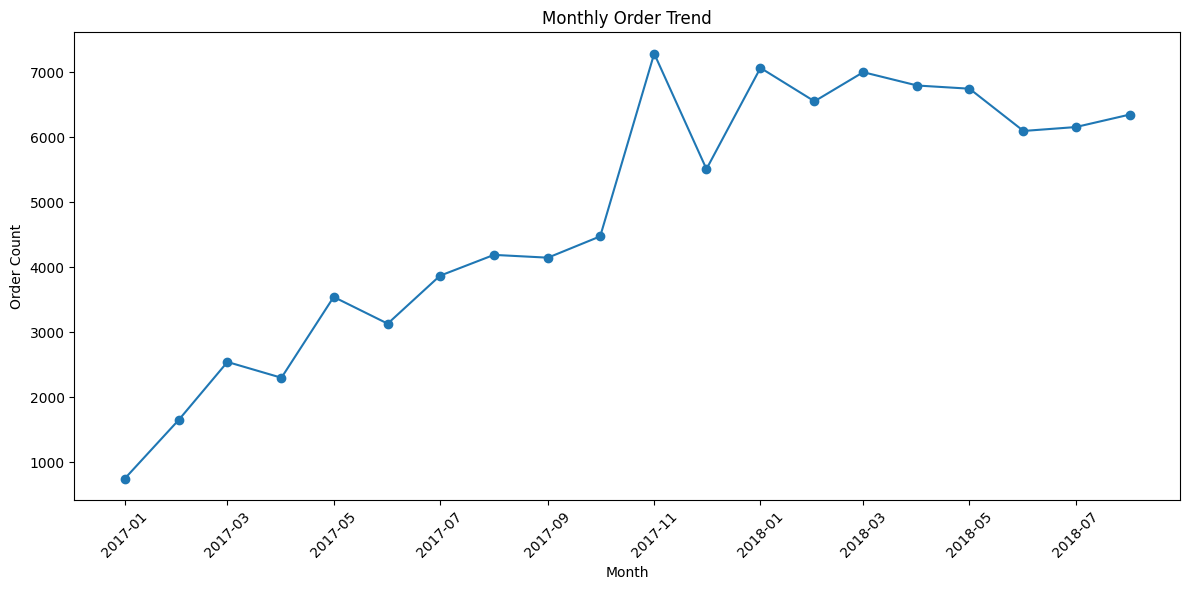

In [12]:
# 月度订单数折线图
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales_analysis["months"],
    monthly_sales_analysis["m_order_count"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Order Count")
plt.title("Monthly Order Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 计算销售额与订单数两组数据的相关性，相关系数越接近1则相关性越强
print(monthly_sales_analysis[["m_total_sales", "m_order_count"]].corr())

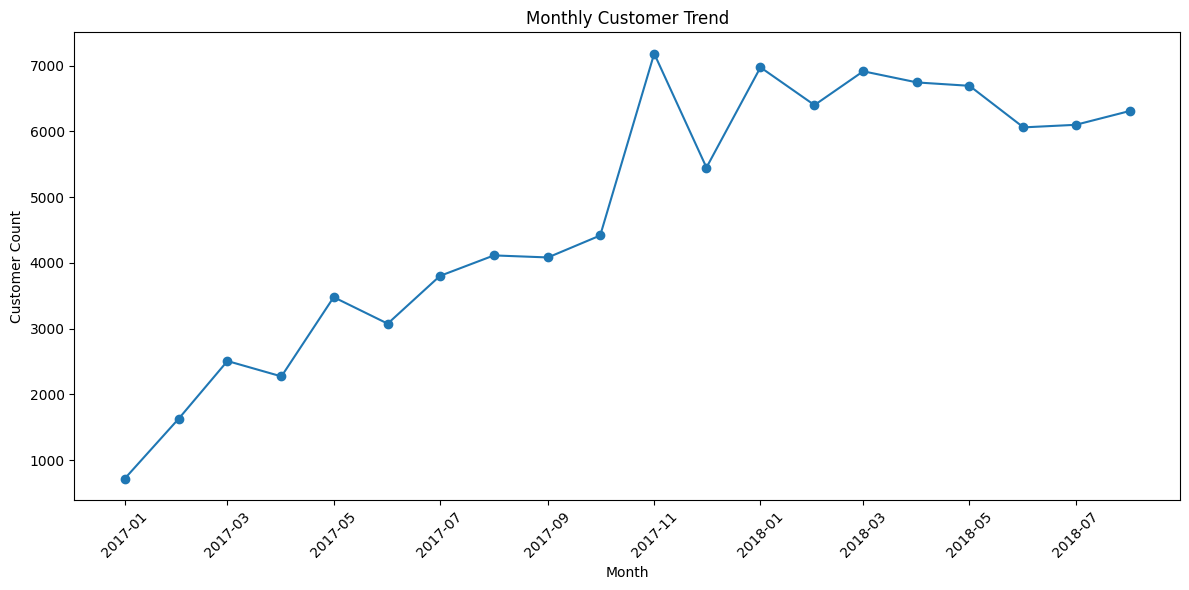

                  m_total_sales  m_customer_count
m_total_sales          1.000000          0.993573
m_customer_count       0.993573          1.000000


In [14]:
# 月度客户数折线图
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales_analysis["months"],
    monthly_sales_analysis["m_customer_count"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Customer Count")
plt.title("Monthly Customer Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 销售额与客户数的相关性
print(monthly_sales_analysis[["m_total_sales", "m_customer_count"]].corr())

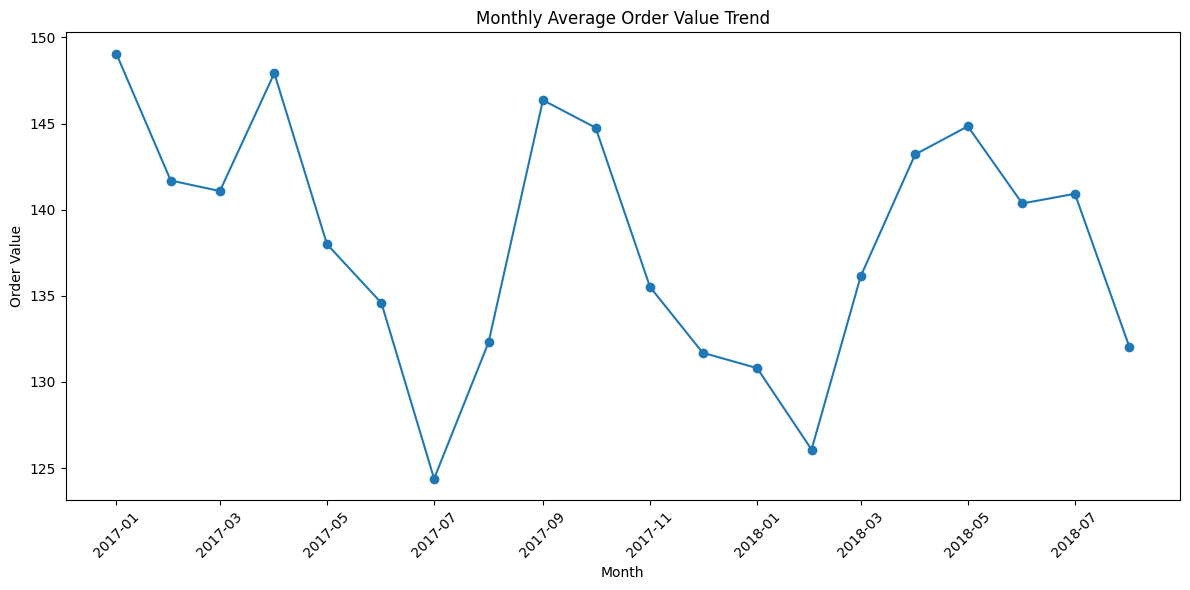

                   m_total_sales  m_avg_order_value
m_total_sales            1.00000           -0.27909
m_avg_order_value       -0.27909            1.00000


In [15]:
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales_analysis["months"],
    monthly_sales_analysis["m_avg_order_value"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Order Value")
plt.title("Monthly Average Order Value Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 销售额与客单价的相关性
print(monthly_sales_analysis[["m_total_sales", "m_avg_order_value"]].corr())